In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import pandas as pd

import os
import tqdm
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device


'cuda:0'

In [2]:
def load_cifar100_splits(n_train=1000, n_cal=1000, n_test=1000):
    """
    Restituisce 3 split: train, calibration, test dal dataset CIFAR-100
    """
    transform = T.ToTensor()

    # Carica il dataset train CIFAR-100
    trainset = torchvision.datasets.CIFAR100(
        root='./data', train=True, download=True, transform=transform
    )

    # Permutazione casuale
    perm = torch.randperm(len(trainset))

    idx_train = perm[:n_train]
    idx_cal   = perm[n_train:n_train+n_cal]
    idx_test  = perm[n_train+n_cal:n_train+n_cal+n_test]

    # Estrazione rapida degli esempi
    X_train = torch.stack([trainset[i][0] for i in idx_train])
    y_train = torch.tensor([trainset[i][1] for i in idx_train])

    X_cal   = torch.stack([trainset[i][0] for i in idx_cal])
    y_cal   = torch.tensor([trainset[i][1] for i in idx_cal])

    X_test  = torch.stack([trainset[i][0] for i in idx_test])
    y_test  = torch.tensor([trainset[i][1] for i in idx_test])

    return (X_train, y_train), (X_cal, y_cal), (X_test, y_test)

In [3]:
(train_X, train_y), (cal_X, cal_y), (test_X, test_y) = load_cifar100_splits()
train_X.shape, cal_X.shape, test_X.shape

(torch.Size([1000, 3, 32, 32]),
 torch.Size([1000, 3, 32, 32]),
 torch.Size([1000, 3, 32, 32]))

In [43]:
net = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AvgPool2d(2, 2),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AvgPool2d(2, 2),
                nn.Dropout(0.4),
                nn.Conv2d(64, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AvgPool2d(2, 2),
                nn.Dropout(0.4),
                nn.Flatten(),
                nn.Linear(1024,256),
                nn.ReLU(),
                nn.Linear(256, 100)
            )

net = net.to(device)


In [44]:
ckptPath = "/home/acarlevaro/Sources/albi/AdversarialCP_old/Verifiably_Robust_CP/VRCP_Classification/Checkpoints/"

print("==> Loading checkpoint...")
checkpoint = torch.load(ckptPath + "cifar100CNN.pth", map_location=device)

net.load_state_dict(checkpoint["net"])
best_acc = checkpoint["acc"]
start_epoch = checkpoint["epoch"]

print("Loaded. Best acc:", best_acc)


==> Loading checkpoint...
Loaded. Best acc: 55.73


In [45]:
train_loader = torch.utils.data.DataLoader(
    list(zip(train_X, train_y)), batch_size=256, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    list(zip(test_X, test_y)), batch_size=256, shuffle=False
)


## Se vuoi riaddestrare....

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001)

EPOCHS = 10

net.train()
for epoch in range(EPOCHS):
    running_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)

        optimizer.zero_grad()
        out = net(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, loss = {running_loss:.3f}")


### Test the net

In [7]:
net.eval()
correct = 0
total = 0

with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        preds = net(Xb).argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

print(f"Accuracy on test split: {correct/total:.2%}")


Accuracy on test split: 67.00%


### BINCP

In [8]:
# %%
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ------------------------------
# Step 1: Load your simple net
# ------------------------------
class SimpleCNN100(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        
        # Blocchi convoluzionali
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        
        self.pool = nn.AvgPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.4)
        self.dropout2 = nn.Dropout(0.4)
        self.flatten = nn.Flatten()
        
        # Calcolo dimensione finale dopo convoluzioni + pooling:
        # CIFAR-100 input: 32x32
        # conv1 + pool -> 16x16
        # conv2 + pool -> 8x8
        # conv3 + pool -> 4x4
        # channels = 64
        self.fc1 = nn.Linear(64 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        
        x = F.relu(self.conv3(x))
        x = self.pool(x)
        x = self.dropout2(x)
        
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN100().to(device)
model.eval()  # ensure model is in eval mode



SimpleCNN100(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (dropout1): Dropout(p=0.4, inplace=False)
  (dropout2): Dropout(p=0.4, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1024, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=100, bias=True)
)

In [9]:
# ------------------------------
# Step 2: Load CIFAR-10 subset
# ------------------------------
import torchvision
import torchvision.transforms as T

transform = T.ToTensor()
trainset = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform)

# small subset for calibration example
n_cal = 1000
cal_indices = torch.randperm(len(trainset))[:n_cal]

X_cal = torch.stack([trainset[i][0] for i in cal_indices]).to(device)
y_cal = torch.tensor([trainset[i][1] for i in cal_indices]).to(device)

In [20]:
# ------------------------------
# Step 3: Define BINCP score function
# ------------------------------
def smoothed_score(model, x, sigma=0.5):
    """Compute nonconformity score on x + epsilon, where epsilon ~ N(0, sigma^2)."""
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    # score = 1 - probability of true class
    score = 1 - probs.gather(1, cal_y.to(device).view(-1,1)).squeeze()
    return score

In [21]:
# ------------------------------
# Step 4: Calibration
# ------------------------------
sigma = 0.06
scores = smoothed_score(model, cal_X.to(device), sigma=sigma)
alpha = 0.1  # desired miscoverage rate
q_hat = np.quantile(scores.detach().cpu().numpy(), 1 - alpha)  # conformal threshold

print(f"Calibration threshold q_hat = {q_hat:.4f}")

Calibration threshold q_hat = 0.9906


In [22]:
# ------------------------------
# Step 5: Prediction / conformal set
# ------------------------------
def conformal_set(model, x, q_hat, sigma=0.06):
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    # include all classes with score <= q_hat
    scores = 1 - probs
    sets = [torch.where(s <= q_hat)[0] for s in scores]
    return sets

# Test example
x_test = cal_X[:5].to(device)  # example test batch
sets = conformal_set(model, x_test, q_hat, sigma=sigma)
for i, s in enumerate(sets):
    print(f"Example {i} conformal set: {s}")


Example 0 conformal set: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36,
        37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55, 56,
        57, 58, 60, 61, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 75, 76, 77, 78,
        79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98,
        99], device='cuda:0')
Example 1 conformal set: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
        36, 37, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 55,
        56, 57, 58, 60, 61, 63, 64, 65, 66, 67, 68, 69, 71, 72, 73, 75, 76, 77,
        78, 79, 80, 81, 82, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97,
        98, 99], device='cuda:0')
Example 2 conformal set: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 1

In [66]:
import torch
import torch.nn.functional as F
import time
import numpy as np

def smoothed_score(model, x, sigma=0.12):
    """Compute nonconformity scores on x + epsilon, epsilon ~ N(0, sigma^2)."""
    epsilon = torch.randn_like(x) * sigma
    logits = model(x + epsilon)
    probs = F.softmax(logits, dim=1)
    score = 1 - probs  # shape [1, num_classes]
    return score

def evaluate_conformal_smoothed(model, X_cal, y_cal, X_test, y_test, alpha=0.1, sigma=0.5, device='cuda'): 
    """
    Evaluate smoothed conformal prediction.
    Returns:
    - coverage_mean, coverage_std, coverage_CI95
    - size_mean, size_std, size_CI95
    - time_mean, time_std
    - epsilon
    """
    model.eval()
    model.to(device)

    X_cal, y_cal = X_cal.to(device), y_cal.to(device)
    X_test, y_test = X_test.to(device), y_test.to(device)

    # --------
    # 1. Calibration
    # --------
    cal_scores = []
    with torch.no_grad():
        for i in range(len(X_cal)):
            scores_i = smoothed_score(model, X_cal[i:i+1], sigma=sigma)
            score_true = scores_i[0, y_cal[i]]
            cal_scores.append(score_true.item())

    cal_scores = np.array(cal_scores)
    q_hat = np.quantile(cal_scores, 1 - alpha)

    # --------
    # 2. Test evaluation
    # --------
    coverages = []
    set_sizes = []
    times = []

    with torch.no_grad():
        for i in range(len(X_test)):
            start_time = time.time()
            scores_i = smoothed_score(model, X_test[i:i+1], sigma=sigma)

            conf_set = torch.nonzero(scores_i <= q_hat, as_tuple=False)[:,1]
            end_time = time.time()

            set_sizes.append(len(conf_set))
            times.append(end_time - start_time)

            coverages.append(int(y_test[i].item() in conf_set))

    coverages = np.array(coverages)
    set_sizes = np.array(set_sizes)
    times = np.array(times)

    # --------
    # 3. Compute metrics
    #--------
    coverage_mean = coverages.mean()
    coverage_std  = coverages.std()
    coverage_CI95 = 1.96 * coverage_std / np.sqrt(len(coverages))

    size_mean = set_sizes.mean()
    size_std  = set_sizes.std()
    size_CI95 = 1.96 * size_std / np.sqrt(len(set_sizes))

    time_mean = times.mean()
    time_std  = times.std()

    return (coverage_mean, coverage_std, coverage_CI95,
            size_mean, size_std, size_CI95,
            time_mean, time_std
            )



### Vanilla

In [67]:
(
    coverage_mean, coverage_std, coverage_CI95,
    size_mean, size_std, size_CI95,
    time_mean, time_std
) = evaluate_conformal_smoothed(
        model=net,
        X_cal=cal_X,
        y_cal=cal_y,
        X_test=test_X,
        y_test=test_y,
        alpha=0.1,
        sigma=2*0.03,
        device='cuda:0'
)

print(f"Coverage: {coverage_mean:.3f} ± {coverage_CI95:.3f}")
print(f"Average set size: {size_mean:.3f} ± {size_CI95:.3f}")
print(f"Average time (s): {time_mean:.4f} (std {time_std:.4f})")


Coverage: 0.898 ± 0.019
Average set size: 7.048 ± 0.248
Average time (s): 0.0008 (std 0.0000)


In [36]:
import torch
import torch.nn.functional as F

def pgd_l2(
    model,
    x,
    y,
    epsilon,
    step_size=1/255,
    num_steps=100,
    device="cuda"
):
    """
    L2-constrained PGD attack.
    """
    model.eval()
    x = x.to(device)
    y = y.to(device)

    # Start from the clean point
    x_adv = x.clone().detach()

    # Random initialization (optional but common)
    noise = torch.randn_like(x_adv)
    noise = noise / (noise.view(len(x), -1).norm(dim=1).view(-1,1,1,1) + 1e-8)
    x_adv = (x_adv + epsilon * noise).clone().detach()
    x_adv = x_adv.clamp(0, 1)

    for _ in range(num_steps):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)

        grad = torch.autograd.grad(loss, x_adv)[0]

        # Normalize gradient to L2 unit norm
        grad_norm = grad.view(len(x), -1).norm(dim=1).view(-1,1,1,1)
        grad_unit = grad / (grad_norm + 1e-12)

        # Gradient ascent step
        x_adv = x_adv + step_size * grad_unit

        # Project back to L2 ball
        delta = x_adv - x
        delta_norm = delta.view(len(x), -1).norm(dim=1).view(-1,1,1,1)
        delta = delta * torch.clamp(epsilon / (delta_norm + 1e-12), max=1.0)

        x_adv = (x + delta).clamp(0, 1).detach()

    return x_adv


In [37]:
def generate_pgd_dataset(model, X, y, dataset="cifar10", device="cuda", eps = 0.03):
    #if dataset.lower() == "cifar10":
    #    eps = 0.03
    #elif dataset.lower() in ["cifar100", "tinyimagenet"]:
    #    eps = 0.02
    #else:
    #    raise ValueError("Unknown dataset")

    X_adv_list = []
    batch_size = 64  # adjust as needed

    model.eval()

    print(eps)
    
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].to(device)
        yb = y[i:i+batch_size].to(device)

        X_adv = pgd_l2(
            model=model,
            x=xb,
            y=yb,
            epsilon=eps,
            step_size=1/255,
            num_steps=100,
            device=device
        )

        X_adv_list.append(X_adv.cpu())

    return torch.cat(X_adv_list, dim=0)


In [68]:
X_test_adv = generate_pgd_dataset(
    model=net,
    X=test_X,
    y=test_y,
    dataset="cifar100",
    device="cuda:0"
)

print("Adversarial dataset shape:", X_test_adv.shape)


0.03
Adversarial dataset shape: torch.Size([1000, 3, 32, 32])


### Attacked

In [69]:
(
    coverage_mean, coverage_std, coverage_CI95,
    size_mean, size_std, size_CI95,
    time_mean, time_std
) = evaluate_conformal_smoothed(
        model=net,
        X_cal=cal_X,
        y_cal=cal_y,
        X_test=X_test_adv,
        y_test=test_y,
        alpha=0.1,
        sigma=2*0.03,
        device='cuda:0'
)

print(f"Coverage: {coverage_mean:.3f} ± {coverage_CI95:.3f}")
print(f"Average set size: {size_mean:.3f} ± {size_CI95:.3f}")
print(f"Average time (s): {time_mean:.4f} (std {time_std:.4f})")

Coverage: 0.887 ± 0.020
Average set size: 7.278 ± 0.257
Average time (s): 0.0009 (std 0.0001)


In [72]:
#def smoothed_score(model, x, y, sigma=0.5):
#    eps = torch.randn_like(x) * sigma
#    logits = model(x + eps)
#    probs = F.softmax(logits, dim=1)
#    return (1 - probs.gather(1, y.view(-1,1)).squeeze()).detach()

def compute_BINCP(model, X_cal, y_cal, X_test, y_test, eps, sigma=0.5, device='cuda:0'):
    """
    Compute BINCP under PGD attack using smoothed conformal evaluation.
    """
    print(eps)
    # 1. Generate PGD-attacked dataset
    X_test_adv = generate_pgd_dataset(
        model, 
        X_test, 
        y_test, 
        dataset="cifar100", 
        device=device, 
        eps=eps
    )
    
    print("sigma",sigma)
    # 2. Evaluate using the unified conformal function
    (
        coverage_mean, coverage_std, coverage_CI95,
        size_mean, size_std, size_CI95,
        time_mean, time_std
    ) = evaluate_conformal_smoothed(
        model=model,
        X_cal=X_cal,
        y_cal=y_cal,
        X_test=X_test_adv,
        y_test=y_test,
        alpha=0.1,
        sigma=sigma,
        device=device
    )

    print("size:",size_mean)
    
    # 3. Return a dictionary fully compatible with your CSV
    return {
        "epsilon": eps,
        "coverage_mean": coverage_mean,
        "coverage_std": coverage_std,
        "coverage_CI95": coverage_CI95,
        "size_mean": size_mean,
        "size_std": size_std,
        "size_CI95": size_CI95,
        "time_mean": time_mean,
        "time_std": time_std
    }


def bincp_predict_set(model, x, qhat, sigma=0.5):
    x = x.unsqueeze(0)  # single item
    scores = []
    with torch.no_grad():
        for cls in range(100):
            eps = torch.randn_like(x) * sigma
            logits = model(x + eps)
            probs = F.softmax(logits, dim=1)
            scores.append(1 - probs[0, cls].item())
    scores = np.array(scores)
    return (scores <= qhat).astype(int)

In [73]:
epsilons_VRCP = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
epsilons_extra = np.linspace(0.1, 5.0, 10)
all_eps = list(epsilons_VRCP) + list(epsilons_extra)

results = []
for eps in tqdm.tqdm(all_eps):
    stats = compute_BINCP(
        net,
        cal_X, cal_y,
        test_X, test_y,
        eps=eps,
        sigma=2*eps
    )
    stats["epsilon"] = eps
    results.append(stats)

df = pd.DataFrame(results)
df.to_csv("BINCP_results_CIFAR100.csv", index=False)
print("Saved BINCP_results_CIFAR100.csv!")

  0%|          | 0/20 [00:00<?, ?it/s]

0.005
0.005
sigma 0.01


  5%|▌         | 1/20 [00:04<01:25,  4.52s/it]

size: 3.083
0.01
0.01
sigma 0.02


 10%|█         | 2/20 [00:09<01:22,  4.61s/it]

...

size: 100.0
4.455555555555556
4.455555555555556
sigma 8.911111111111111


 95%|█████████▌| 19/20 [01:31<00:05,  5.01s/it]

size: 100.0
5.0
5.0
sigma 10.0


100%|██████████| 20/20 [01:36<00:00,  4.83s/it]

size: 100.0
Saved BINCP_results_CIFAR100.csv!


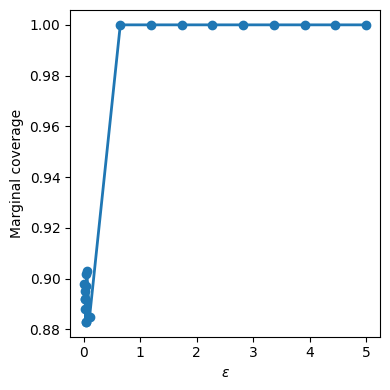

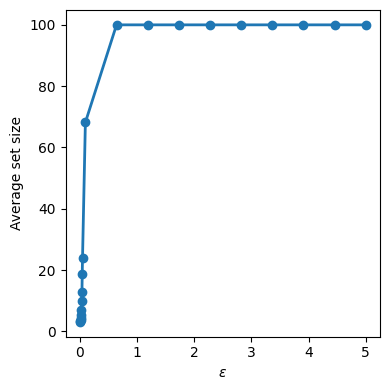

In [78]:
import matplotlib.pyplot as plt
"""
df must contain:
    epsilon, coverage_mean, size_mean
"""

eps = df["epsilon"].values
cov = df["coverage_mean"].values
size = df["size_mean"].values

# ------------------------------------
# 1. PLOT COVERAGE vs EPSILON
# ------------------------------------
plt.figure(figsize=(4,4))
plt.plot(eps, cov, marker="o", linewidth=2)
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Marginal coverage")
plt.tight_layout()
plt.show()

# ------------------------------------
# 2. PLOT AVERAGE SET SIZE vs EPSILON
# ------------------------------------
plt.figure(figsize=(4,4))
plt.plot(eps, size, marker="o", linewidth=2)
plt.xlabel(r"$\varepsilon$")
plt.ylabel("Average set size")
plt.tight_layout()
plt.show()

### RCP1

In [62]:
model = net.eval()

In [63]:
import torch
import torch.nn.functional as F
import math
import time

class RCP1:
    def __init__(self, model, alpha=0.1, sigma=0.5, device='cuda'):
        self.model = model.to(device)
        self.alpha = alpha
        self.sigma = sigma
        self.device = device
        self.threshold = None

    def score(self, x, y=None):
        """Compute smoothed nonconformity score."""
        x = x.to(self.device)
        eps = torch.randn_like(x) * self.sigma
        logits = self.model(x + eps)
        probs = F.softmax(logits, dim=1)

        if y is not None:
            y = y.to(self.device)
            scores = 1 - probs.gather(1, y.view(-1,1)).squeeze()
        else:
            # fallback: score rispetto alla classe predetta
            scores = 1 - probs.max(dim=1).values
        return scores, probs

    def calibrate(self, x_cal, y_cal):
        """Calibrate quantile threshold using calibration set."""
        scores, _ = self.score(x_cal, y_cal)
        scores_sorted = torch.sort(scores)[0]
        n = scores.shape[0]
        k = math.ceil((n + 1) * (1 - self.alpha)) - 1
        k = max(0, min(k, n - 1))
        self.threshold = scores_sorted[k].item()
        return self.threshold

    def predict_multiclass(self, x_test):
        """Return multiclass pred_set [batch, num_classes]."""
        x_test = x_test.to(self.device)
        eps = torch.randn_like(x_test) * self.sigma
        logits = self.model(x_test + eps)
        probs = F.softmax(logits, dim=1)
        # score per ogni classe
        scores = 1 - probs  # shape [batch, num_classes]
        pred_set = scores <= self.threshold  # shape [batch, num_classes]
        return pred_set, probs.argmax(dim=1), scores


In [64]:
def evaluate_cp_multiclass(cp_model, test_X, test_y, device='cuda', num_mc=1):
    test_X = test_X.to(device)
    test_y = test_y.to(device)
    
    n = len(test_X)
    coverages = []
    set_sizes = []
    times_list = []
    
    for i in range(n):
        x = test_X[i].unsqueeze(0)
        y = test_y[i].unsqueeze(0)
        
        start = time.time()
        pred_set, y_hat, scores = cp_model.predict_multiclass(x)
        elapsed = time.time() - start
        
        # Coverage = pred_set contiene la classe vera
        coverage = pred_set[0, y.item()].float().item()
        set_size = pred_set.sum().item()  # numero di classi incluse nel set
        
        coverages.append(coverage)
        set_sizes.append(set_size)
        times_list.append(elapsed)
    
    def mean_ci(values):
        v = torch.tensor(values, dtype=torch.float32)
        mean = v.mean().item()
        ci = 1.96 * v.std(unbiased=True).item() / math.sqrt(len(v))
        return mean, ci
    
    cov_mean, cov_ci = mean_ci(coverages)
    size_mean, size_ci = mean_ci(set_sizes)
    time_mean, time_ci = mean_ci(times_list)
    
    return cov_mean, cov_ci, size_mean, size_ci, time_mean, time_ci


In [69]:
device = torch.device('cuda')

# Istanza CP
cp = RCP1(model, alpha=0.1, sigma=2*0.02, device=device)

# Calibrazione
cp.calibrate(cal_X.to(device), cal_y.to(device))

# Valutazione
cov_mean, cov_ci, size_mean, size_ci, time_mean, time_ci = evaluate_cp_multiclass(
    cp_model=cp,
    test_X=X_test_adv,
    test_y=test_y,
    device=device
)

print(f"Marginal coverage: {cov_mean:.2f} ± {cov_ci:.2f}")
print(f"Average set size: {size_mean:.2f} ± {size_ci:.2f}")
print(f"Average time: {time_mean:.4f} ± {time_ci:.4f} s")


Marginal coverage: 0.90 ± 0.03
Average set size: 5.42 ± 0.26
Average time: 0.0008 ± 0.0000 s


In [47]:
def evaluate_RCP1_with_attack(cp_model, X_cal, y_cal, X_test, y_test, eps, sigma=0.5, device="cuda"):

    # ---- 1. Attacco PGD L2 ----
    X_test_adv = pgd_l2_attack(cp_model.model, X_test, y_test, eps=eps)

    # ---- 2. Calibrazione ----
    cp_model.sigma = sigma
    cp_model.calibrate(X_cal, y_cal)

    # ---- 3. Valutazione ----
    n = len(X_test_adv)
    coverages = []
    sizes = []
    times_list = []

    for i in range(n):
        x = X_test_adv[i].unsqueeze(0)
        y = y_test[i].unsqueeze(0)

        start = time.time()
        pred_set, y_hat, scores = cp_model.predict_multiclass(x)
        elapsed = time.time() - start

        # Coverage
        coverages.append(pred_set[0, y.item()].float().item())

        # Set size
        sizes.append(pred_set.sum().item())

        # Time
        times_list.append(elapsed)

    # ---- 4. Mean + 95% CI ----
    def mean_ci(vals):
        v = torch.tensor(vals, dtype=torch.float32)
        m = v.mean().item()
        ci = 1.96 * v.std(unbiased=True).item() / math.sqrt(len(vals))
        return m, ci

    cov_mean, cov_ci = mean_ci(coverages)
    size_mean, size_ci = mean_ci(sizes)
    time_mean, time_ci = mean_ci(times_list)

    return {
        "coverage_mean": cov_mean,
        "coverage_CI95": cov_ci,
        "size_mean": size_mean,
        "size_CI95": size_ci,
        "time_mean": time_mean,
        "time_CI95": time_ci,
    }


In [50]:
import pandas as pd
import tqdm
import numpy as np

# Lista epsilon come nel tuo esempio
epsilons_VRCP = [0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045, 0.05]
epsilons_extra = np.linspace(0.1, 5.0, 10)
all_eps = list(epsilons_VRCP) + list(epsilons_extra)

results = []

# Inizializza il tuo CP model
cp = RCP1(model, alpha=0.1, sigma=0.05, device=device)

for eps in tqdm.tqdm(all_eps):
    stats = evaluate_RCP1_with_attack(
        cp, 
        X_cal, y_cal,
        test_X, test_y,
        eps=eps,
        sigma=2*eps
    )
    stats["epsilon"] = eps
    results.append(stats)

df = pd.DataFrame(results)
df.to_csv("RCP1_results.csv", index=False)
print("Saved RCP1_results.csv!")


100%|██████████| 20/20 [00:13<00:00,  1.50it/s]

Saved RCP1_results.csv!
